In [1]:
import json
import os
import urllib

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as f:
            f.write(text_data)

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    return data

In [2]:
file_path = "../data/instruction-data.json"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json"

data = download_and_load_file(file_path, url)
print(f"Number of entries: {len(data)}")

Number of entries: 1100


In [3]:
data[1]

{'instruction': 'Edit the following sentence for grammar.',
 'input': 'He go to the park every day.',
 'output': 'He goes to the park every day.'}

In [4]:
def format_input(entry, prompt_style="alpaca"):
    if prompt_style == "alpaca":
        instruction_text = (
            f"Below is an instruction that describes a task. "
            f"Write a response that appropriately completes the request."
            f"\n\n### Instruction:\n{entry['instruction']}"
        )

        input_text = (
            f"\n\n### Input:\n{entry['input']}" if entry['input'] else ""
        )

        return instruction_text + input_text
    elif prompt_style == "phi-3":
        punc = entry['instruction'][-1]
        user_request = f"<|user|>\n{entry['instruction'][:-1]}"
        if entry['input']:
            user_request += f": {entry['input']}"
        else:
            user_request += punc
        return user_request
    else:
        raise ValueError(f"'{prompt_style}' is not a recognized prompt style.")

In [5]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [6]:
model_input = format_input(data[50], prompt_style="phi-3")
desired_response = f"\n\n<|assistant|>\n{data[50]['output']}"
print(model_input + desired_response)

<|user|>
Identify the correct spelling of the following word: Ocassion

<|assistant|>
The correct spelling is 'Occasion.'


In [7]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

print("-------------")

model_input = format_input(data[999], prompt_style="phi-3")
desired_response = f"\n\n<|assistant|>\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.
-------------
<|user|>
What is an antonym of 'complicated'?

<|assistant|>
An antonym of 'complicated' is 'simple'.


In [8]:
def full_instruction_prompt(entry, prompt_style="alpaca"):
    model_input = format_input(entry, prompt_style)
    if prompt_style == "alpaca":
        desired_response = f"\n\n### Response:\n{entry['output']}"
    elif prompt_style == "phi-3":
        desired_response = f"\n\n<|assistant|>\n{entry['output']}"
    else:
        # This is actually impossible, but just in case (as model_input will already raise an input before we get into the if-else block)
        raise ValueError(f"'{prompt_style}' is not a recognized prompt style.")
    return model_input + desired_response

In [9]:
# Exercise 6.2
def full_instruction_prompt_tokenize(entry, tokenizer, prompt_style="alpaca"):
    model_input_tokenized = tokenizer.encode(format_input(entry, prompt_style))
    if prompt_style == "alpaca":
        desired_response = f"\n\n### Response:\n{entry['output']}"
    elif prompt_style == "phi-3":
        desired_response = f"\n\n<|assistant|>\n{entry['output']}"
    else:
        raise ValueError(f"'{prompt_style}' is not a recognized prompt style.")
    return model_input_tokenized, tokenizer.encode(desired_response)

In [10]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion+test_portion:]

print(f"Training set length: {len(train_data)}")
print(f"Validation set length: {len(val_data)}")
print(f"Test set length: {len(test_data)}")

Training set length: 935
Validation set length: 55
Test set length: 110


### Data Loaders

In [11]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer, prompt_style="alpaca"):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            self.encoded_texts.append(full_instruction_prompt_tokenize(entry, tokenizer, prompt_style))

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)
            

In [12]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [13]:
def custom_collate_draft_1(batch, pad_token_id=50256, device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch) # 6
    inputs_lst = list()
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [14]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (inputs_1, inputs_2, inputs_3)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [15]:
# Now with the targets
def custom_collate_draft_2(batch, pad_token_id=50256, device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = list(), list()

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [16]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


In [17]:
torch.nonzero((torch.tensor(batch[0]) == 1) | (torch.tensor(batch[0]) == 2)).shape

torch.Size([2, 1])

In [18]:
# Change the repeating "endoftext" tokens into -100 to discard them from loss calculation
# Because in pytorch, cross_entropy loss has -100 as the ignore index: cross_entropy(..., ignore_index=-100)
def custom_collate_fn(batch, pad_token_id=50256, ignore_index=-100, allowed_max_length=None, device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch) # Maximum length, including the "target" (so input sequence + 1)
    # and that +1 will make it possible to "shift" the text
    inputs_lst, targets_lst = list(), list()

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id] # Pre-emptively pad the sequence by 1
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item)) # It is padded until max(len(input)) + 1

        # Shift the sequence within itself to get the targets
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        mask = targets == pad_token_id # Mask for whereever we introduced the <|endoftext|> token
        indices = torch.nonzero(mask).squeeze() # torch.nonzero returns a 2D tensor, each row having the index of a nonzero value
        # i.e. the number of rows in the torch.nonzero(mask) is the number of non-zero elements in the sequence
        if indices.numel() > 1: # If the targets has more than 1 <|endoftext|>
            targets[indices[1:]] = ignore_index
        
        # Set to the context length of the model
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)
    
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor


In [19]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [20]:
def custom_collate_fn(batch, pad_token_id=50256,
                      ignore_index=-100,
                      allowed_max_length=None,
                      device="cpu",
                      mask_instructions=False):
    batch_max_length = max(len(item[0] + item[1]) for item in batch) + 1
    inputs_lst, targets_lst = list(), list()

    for item in batch:
        instruction_length = len(item[0])
        new_item = item[0].copy() + item[1].copy()
        new_item += [pad_token_id]
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))

        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        if mask_instructions:
            targets[:instruction_length-1] = ignore_index
        
        # Set to the context length of the model
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)
    
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [21]:
batch = (
    [[0, 1], [2, 3, 4]],
    [[5], [6]],
    [[7, 8, 9, 10], [11, 12, 13, 14, 15]]
)

In [22]:
inputs, targets = custom_collate_fn(batch, mask_instructions=True)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4, 50256, 50256, 50256, 50256],
        [    5,     6, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
        [    7,     8,     9,    10,    11,    12,    13,    14,    15]])
tensor([[ -100,     2,     3,     4, 50256,  -100,  -100,  -100,  -100],
        [    6, 50256,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
        [ -100,  -100,  -100,    11,    12,    13,    14,    15, 50256]])


In [23]:
device = torch.device("cuda")

In [24]:
from functools import partial

customized_collate_fn = partial(custom_collate_fn,
    device=device,
    allowed_max_length=1024)

instruction_masking_collate_fn = partial(custom_collate_fn,
    device=device,
    allowed_max_length=1024,
    mask_instructions=True)

In [25]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 32

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [26]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([32, 76]) torch.Size([32, 76])
torch.Size([32, 80]) torch.Size([32, 80])
torch.Size([32, 75]) torch.Size([32, 75])
torch.Size([32, 79]) torch.Size([32, 79])
torch.Size([32, 83]) torch.Size([32, 83])
torch.Size([32, 80]) torch.Size([32, 80])
torch.Size([32, 69]) torch.Size([32, 69])
torch.Size([32, 76]) torch.Size([32, 76])
torch.Size([32, 91]) torch.Size([32, 91])
torch.Size([32, 67]) torch.Size([32, 67])
torch.Size([32, 89]) torch.Size([32, 89])
torch.Size([32, 83]) torch.Size([32, 83])
torch.Size([32, 76]) torch.Size([32, 76])
torch.Size([32, 83]) torch.Size([32, 83])
torch.Size([32, 80]) torch.Size([32, 80])
torch.Size([32, 71]) torch.Size([32, 71])
torch.Size([32, 87]) torch.Size([32, 87])
torch.Size([32, 71]) torch.Size([32, 71])
torch.Size([32, 71]) torch.Size([32, 71])
torch.Size([32, 72]) torch.Size([32, 72])
torch.Size([32, 72]) torch.Size([32, 72])
torch.Size([32, 74]) torch.Size([32, 74])
torch.Size([32, 91]) torch.Size([32, 91])
torch.Size([32, 81])

In [27]:
from gpt_download import download_and_load_gpt2
from gpt_modules import GPTModel
from weight_loader import load_weights_into_gpt

2025-11-30 18:47:32.756817: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-30 18:47:32.756940: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-30 18:47:32.758699: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-30 18:47:32.766024: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-30 18:47:33.593764: W tensorflow/compiler/tf2

In [28]:
BASE_CONFIG = {
    "vocab_size": 50_257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}

model_configs = {
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16}
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(
    model_size = model_size,
    models_dir="gpt2"
)

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


In [29]:
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [30]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [31]:
from gpt_training_utils import generate, text_to_token_ids, token_ids_to_text

token_ids = generate(model=model,
                    idx=text_to_token_ids(input_text, tokenizer),
                    max_new_tokens=35,
                    context_size=BASE_CONFIG["context_length"],
                    eos_id=50256)

generated_text = token_ids_to_text(token_ids, tokenizer)

In [32]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


In [33]:
from gpt_training_utils import calc_loss_loader, train_model_with_bells_and_whistles

### Training Base Model (Alpaca-Style Prompts, Instruction Loss Not Ignored)

The code from here is (mostly) the code from the book, where we use Raschka's dataset, in Alpaca instruction style, and loss on instruction tokens is not ignored.
After this section, there will be some code repetition.

Here, only difference is the change in the training loop (based on Appendix D), as I added cosine decay, learning rate warmup and gradient clipping.

In [34]:
model.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [35]:
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
    )

print(f"Training Loss: {train_loss}")
print(f"Validation Loss: {val_loss}")

Training Loss: 3.813137102127075
Validation Loss: 3.8224923610687256


In [36]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=1e-4, weight_decay=0.1
)
num_epochs=3
warmup_steps = int(0.2 * len(train_loader) * num_epochs)

train_losses, val_losses, track_tokens_seen, track_lrs = train_model_with_bells_and_whistles(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq=5,
    eval_iter=1,
    start_context=format_input(val_data[0]),
    tokenizer=tokenizer,
    warmup_steps=warmup_steps,
    initial_lr=1e-5,
    min_lr=1e-5,
)

end_time = time.time()
execution_time_mins = (end_time - start_time) / 60
print(f"Training completed in {execution_time_mins:.2f} minutes.")

Ep 1 (Iter 000000):  Train loss 3.406,  Val loss 3.283
Ep 1 (Iter 000005):  Train loss 1.748,  Val loss 1.683
Ep 1 (Iter 000010):  Train loss 0.863,  Val loss 1.029
Ep 1 (Iter 000015):  Train loss 0.831,  Val loss 0.945
Ep 1 (Iter 000020):  Train loss 0.786,  Val loss 0.900
Ep 1 (Iter 000025):  Train loss 0.700,  Val loss 0.891
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Convert the active sentence to passive: 'The chef cooks the meal every day.'  ### Response: The chef cooks the meal every day.<|endoftext|>The following instruction describes a task. Write a response that appropriately completes the request.  ### Instruction: Rewrite the sentence using a metaphor.  ### Input:
Ep 2 (Iter 000030):  Train loss 0.685,  Val loss 0.851
Ep 2 (Iter 000035):  Train loss 0.588,  Val loss 0.829
Ep 2 (Iter 000040):  Train loss 0.620,  Val loss 0.814
Ep 2 (Iter 000045):  Train loss 0.579,  Val loss 0.792
Ep 2 (Iter 0000

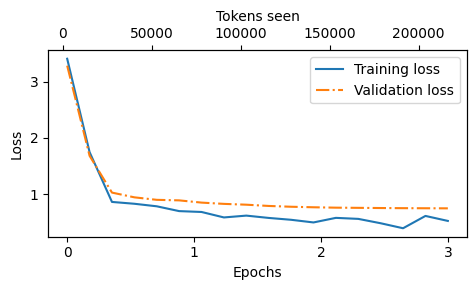

In [37]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, track_tokens_seen, train_losses, val_losses)

In [38]:
# torch.manual_seed(123)
# for entry in test_data:
#     input_text = format_input(entry)
#     token_ids = generate(
#         model=model,
#         idx=text_to_token_ids(input_text, tokenizer).to(device),
#         max_new_tokens=256,
#         context_size = BASE_CONFIG["context_length"],
#         eos_id=50256
#     )
#     generated_text = token_ids_to_text(token_ids, tokenizer)

#     response_text = generated_text[len(input_text):].replace("### Response:", "").strip()
#     print(input_text)
#     print(f"\nCorrect response:\n>> {entry['output']}")
#     print(f"\nModel response:\n>> {response_text}")
#     print("---------------------------------------------")

🤔🤔  
  
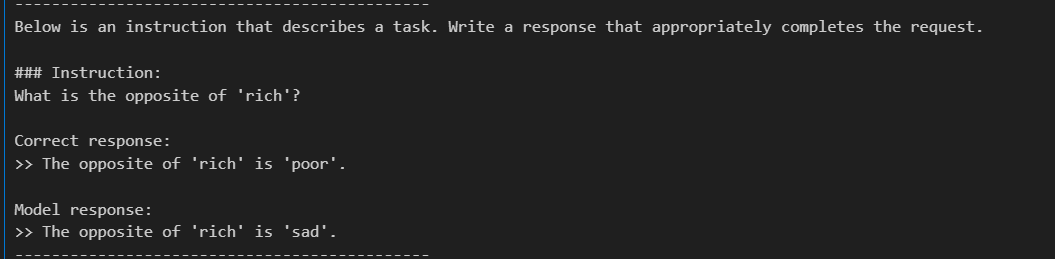

In [39]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size = BASE_CONFIG["context_length"],
        eos_id=50256
    )

    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()
    test_data[i]["model_response"] = response_text

with open("instruction-data-with-response-base.json", "w") as f:
    json.dump(test_data, f, indent=4)

100%|██████████| 110/110 [00:45<00:00,  2.42it/s]


In [40]:
import re

file_name = f"../models/{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft-base.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as ../models/gpt2-medium355M-sft-base.pth


### Training v2 (Alpaca-Style Prompts, Instruction Loss Ignored)

In [41]:
from functools import partial
from torch.utils.data import DataLoader

instruction_masking_collate_fn = partial(custom_collate_fn,
    device=device,
    allowed_max_length=1024,
    mask_instructions=True)

num_workers = 0
batch_size = 32

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=instruction_masking_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=instruction_masking_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=instruction_masking_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
    )

print(f"Training Loss: {train_loss}")
print(f"Validation Loss: {val_loss}")

Training Loss: 2.331354284286499
Validation Loss: 2.3047133684158325


In [42]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=1e-4, weight_decay=0.1
)
num_epochs=3
warmup_steps = int(0.2 * len(train_loader) * num_epochs)

train_losses, val_losses, track_tokens_seen, track_lrs = train_model_with_bells_and_whistles(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq=5,
    eval_iter=1,
    start_context=format_input(val_data[0]),
    tokenizer=tokenizer,
    warmup_steps=warmup_steps,
    initial_lr=1e-5,
    min_lr=1e-5,
)

end_time = time.time()
execution_time_mins = (end_time - start_time) / 60
print(f"Training completed in {execution_time_mins:.2f} minutes.")

Ep 1 (Iter 000000):  Train loss 1.723,  Val loss 1.706
Ep 1 (Iter 000005):  Train loss 1.072,  Val loss 1.149
Ep 1 (Iter 000010):  Train loss 0.796,  Val loss 1.043
Ep 1 (Iter 000015):  Train loss 0.741,  Val loss 0.979
Ep 1 (Iter 000020):  Train loss 0.730,  Val loss 0.974
Ep 1 (Iter 000025):  Train loss 0.590,  Val loss 0.921
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Convert the active sentence to passive: 'The chef cooks the meal every day.'  ### Response: The chef cooks the meal every day.<|endoftext|>The first thing you notice about the new iPhone is that it's a lot bigger than the previous model. It's also a lot thinner, which is a good thing because it
Ep 2 (Iter 000030):  Train loss 0.632,  Val loss 0.895
Ep 2 (Iter 000035):  Train loss 0.436,  Val loss 0.871
Ep 2 (Iter 000040):  Train loss 0.438,  Val loss 0.849
Ep 2 (Iter 000045):  Train loss 0.422,  Val loss 0.835
Ep 2 (Iter 000050):  Train los

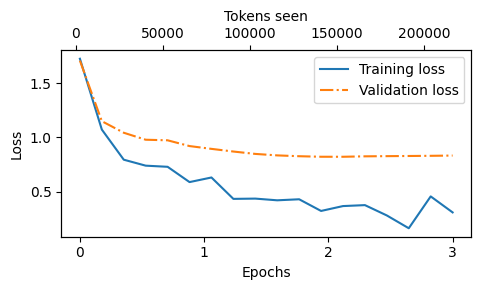

In [43]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, track_tokens_seen, train_losses, val_losses)

In [44]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size = BASE_CONFIG["context_length"],
        eos_id=50256
    )

    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()
    test_data[i]["model_response"] = response_text

with open("instruction-data-with-response-instruction-ignore.json", "w") as f:
    json.dump(test_data, f, indent=4)

100%|██████████| 110/110 [00:49<00:00,  2.23it/s]


### Training v3 (Phi-3-Style Prompts, Instruction loss NOT ignored)

In [45]:
from functools import partial
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 32

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer, prompt_style="phi-3")
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer, prompt_style="phi-3")
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer, prompt_style="phi-3")
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
    )

print(f"Training Loss: {train_loss}")
print(f"Validation Loss: {val_loss}")

Training Loss: 3.6049389362335207
Validation Loss: 3.642679810523987


In [46]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=1e-4, weight_decay=0.1
)
num_epochs=3
warmup_steps = int(0.2 * len(train_loader) * num_epochs)

train_losses, val_losses, track_tokens_seen, track_lrs = train_model_with_bells_and_whistles(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq=5,
    eval_iter=1,
    start_context=format_input(val_data[0], prompt_style="phi-3"),
    tokenizer=tokenizer,
    warmup_steps=warmup_steps,
    initial_lr=1e-5,
    min_lr=1e-5,
)

end_time = time.time()
execution_time_mins = (end_time - start_time) / 60
print(f"Training completed in {execution_time_mins:.2f} minutes.")

Ep 1 (Iter 000000):  Train loss 3.303,  Val loss 3.171
Ep 1 (Iter 000005):  Train loss 1.909,  Val loss 1.790
Ep 1 (Iter 000010):  Train loss 1.122,  Val loss 1.410
Ep 1 (Iter 000015):  Train loss 1.113,  Val loss 1.257
Ep 1 (Iter 000020):  Train loss 1.032,  Val loss 1.240
Ep 1 (Iter 000025):  Train loss 0.967,  Val loss 1.221
<|user|> Convert the active sentence to passive: 'The chef cooks the meal every day.'  <|assistant|> The chef cooks the meal every day.<|endoftext|>The following is a translation of a translation of the French translation of the Italian translation of the Italian translation of the Italian translation of the Italian translation of the Italian translation
Ep 2 (Iter 000030):  Train loss 0.924,  Val loss 1.178
Ep 2 (Iter 000035):  Train loss 0.798,  Val loss 1.138
Ep 2 (Iter 000040):  Train loss 0.812,  Val loss 1.111
Ep 2 (Iter 000045):  Train loss 0.772,  Val loss 1.090
Ep 2 (Iter 000050):  Train loss 0.752,  Val loss 1.075
Ep 2 (Iter 000055):  Train loss 0.702,

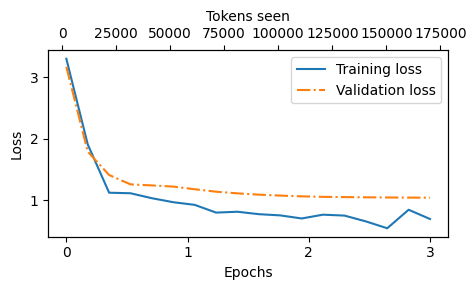

In [47]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, track_tokens_seen, train_losses, val_losses)

In [48]:
for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry, prompt_style="phi-3")

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size = BASE_CONFIG["context_length"],
        eos_id=50256
    )

    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("<|assistant|>", "").strip()
    test_data[i]["model_response"] = response_text

with open("instruction-data-with-response-phi-3.json", "w") as f:
    json.dump(test_data, f, indent=4)

100%|██████████| 110/110 [00:50<00:00,  2.20it/s]


### Training v4 (Phi-3-Style Prompts, Instruction loss ignored)

In [49]:
from functools import partial
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 32

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer, prompt_style="phi-3")
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=instruction_masking_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer, prompt_style="phi-3")
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=instruction_masking_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer, prompt_style="phi-3")
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=instruction_masking_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
    )

print(f"Training Loss: {train_loss}")
print(f"Validation Loss: {val_loss}")

Training Loss: 2.5572414875030516
Validation Loss: 2.5736119747161865


In [50]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=1e-4, weight_decay=0.1
)
num_epochs=3
warmup_steps = int(0.2 * len(train_loader) * num_epochs)

train_losses, val_losses, track_tokens_seen, track_lrs = train_model_with_bells_and_whistles(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq=5,
    eval_iter=1,
    start_context=format_input(val_data[0], prompt_style="phi-3"),
    tokenizer=tokenizer,
    warmup_steps=warmup_steps,
    initial_lr=1e-5,
    min_lr=1e-5,
)

end_time = time.time()
execution_time_mins = (end_time - start_time) / 60
print(f"Training completed in {execution_time_mins:.2f} minutes.")

Ep 1 (Iter 000000):  Train loss 2.262,  Val loss 2.183
Ep 1 (Iter 000005):  Train loss 0.959,  Val loss 1.068
Ep 1 (Iter 000010):  Train loss 0.691,  Val loss 0.914
Ep 1 (Iter 000015):  Train loss 0.667,  Val loss 0.838
Ep 1 (Iter 000020):  Train loss 0.685,  Val loss 0.871
Ep 1 (Iter 000025):  Train loss 0.563,  Val loss 0.838
<|user|> Convert the active sentence to passive: 'The chef cooks the meal every day.'  <|assistant|> The chef cooks the meal every day.<|endoftext|>The U.S. Department of Agriculture (USDA) is a federal agency that is responsible for administering the food safety and nutrition programs of the United States.
Ep 2 (Iter 000030):  Train loss 0.571,  Val loss 0.807
Ep 2 (Iter 000035):  Train loss 0.397,  Val loss 0.782
Ep 2 (Iter 000040):  Train loss 0.415,  Val loss 0.763
Ep 2 (Iter 000045):  Train loss 0.358,  Val loss 0.746
Ep 2 (Iter 000050):  Train loss 0.409,  Val loss 0.740
Ep 2 (Iter 000055):  Train loss 0.282,  Val loss 0.732
<|user|> Convert the active sen

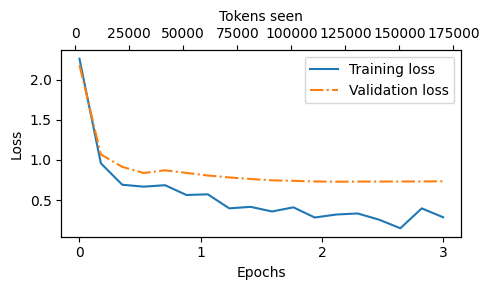

In [51]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, track_tokens_seen, train_losses, val_losses)

In [52]:
for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry, prompt_style="phi-3")

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size = BASE_CONFIG["context_length"],
        eos_id=50256
    )

    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("<|assistant|>", "").strip()
    test_data[i]["model_response"] = response_text

with open("instruction-data-with-response-phi-3-instruction-ignore.json", "w") as f:
    json.dump(test_data, f, indent=4)

100%|██████████| 110/110 [00:53<00:00,  2.06it/s]


### Results


This table has been calculated using LLM-as-a-judge evaluation technique, where a Claude Haiku 4.5 model was asked to score the responses between 0 and 100:

| Method                                            | Score (0 - 100) &#8593;  | Training Time &#8595; |
| ------------------------------------------------- | ------------------------ | --------------------- |
| Alpaca-Style Prompts - Instruction Loss Included  | 34.05                    | 0.72 Minutes          |
| Alpaca-Style Prompts - Instruction Loss Ignored   | **38.99**                | 0.70 Minutes          |
| Phi-3 Style Prompts - Instruction Loss Included   | 33.95                    | 0.59 Minutes          |
| Phi-3 Style Prompts - Instruction Loss Ignored    | 34.97                    | **0.58 Minutes**      |

In this experiment, we observe that ignoring the loss on instruction tokens increase the scores in both instruction styles. Additionally, we observed that Alpaca-style prompts performed better than the Phi-3 style prompts in both cases. Though, because I did not do early stopping or any kind of hyperparameter tuning, this should be taken with a grain of salt.
  
Furthermore, we see that the training time of the Phi-3 style prompts is less than of the Alpaca style ones. I assume this is due to the created sequence length, as the computation time should be lower for shorter sequences:

In [56]:
alpaca_input_sequence = full_instruction_prompt_tokenize(val_data[0], tokenizer)
alpaca_len = len(alpaca_input_sequence[0] + alpaca_input_sequence[1])

phi_input_sequence = full_instruction_prompt_tokenize(val_data[0], tokenizer, prompt_style="phi-3")
phi_len = len(phi_input_sequence[0] + phi_input_sequence[1])

print(f"Length of the sequence in Alpaca: {alpaca_len}")
print(f"Length of the sequence in Phi-3: {phi_len}")

Length of the sequence in Alpaca: 57
Length of the sequence in Phi-3: 42


### TODO's

0. [X] Rent an A100
1. [X] Train instruction-ignored
2. [X] Train Phi-3 style
3. [X] Train Phi-3 and instruction-ignored
4. [X] Add openrouter based verification (llm-as-a-judge) -> Done in "LLM-as-a-judge.ipynb"
5. [ ] Fine-tune on alpaca dataset -> Will be done in its own notebook with the best performing training technique here
6. [ ] Add LoRA Layers and only tune lora params -> Will do it on its own notebook along with the classification